# ReturnLoop — Week 3
## Advanced Data Analysis and Visualization in Logistics

**Project:** ReturnLoop — A Data-Driven Approach to Reverse Logistics, E-Commerce Returns, and Sustainable Recovery

**Input:** `ReturnLoop_Week2_Cleaned_Dataset.csv` (the Week 2 cleaned output — no re-cleaning is performed here)

**Flow:** Dataset Overview & Analysis Readiness → Exploratory Data Analysis → Logistics KPIs → Return Behaviour → Financial Impact → Sustainability Analysis → Relationship & Correlation Analysis → Key Findings → Recommendations → Week 3 Conclusion

## Setup — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

PRIMARY = "#1F5C4B"
SECONDARY = "#3E8E7E"
ACCENT = "#C97B3D"
PALETTE = ["#1F5C4B", "#3E8E7E", "#7FB69E", "#C97B3D", "#A63A3A"]
STATUS_COLORS = {"Returned": "#C97B3D", "Not Returned": "#1F5C4B"}

print("Libraries loaded and plot style configured.")

Libraries loaded and plot style configured.


## Load the Cleaned Dataset

In [2]:
df = pd.read_csv("ReturnLoop_Week2_Cleaned_Dataset.csv")
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 5,000
Columns: 23


## 1. Dataset Overview & Analysis Readiness

### 1.1 Analysis Readiness Check

In [3]:
readiness = {
    "Records": df.shape[0],
    "Variables": df.shape[1],
    "Missing values (total)": int(df.isnull().sum().sum()),
    "Duplicate rows": int(df.duplicated().sum()),
    "Return_Reason logical check": "OK - 'No Return' only for Not Returned orders"
        if (df.loc[df["Return_Status"] == "Not Returned", "Return_Reason"].eq("No Return").all()
            and not df.loc[df["Return_Status"] == "Returned", "Return_Reason"].eq("No Return").any())
        else "MISMATCH FOUND",
    "Days_to_Return logical check": "OK - 0 for every Not Returned order"
        if (df.loc[df["Return_Status"] == "Not Returned", "Days_to_Return"] == 0).all()
        else "MISMATCH FOUND",
    "Return_Cost value check": f"Fixed values only: {sorted(df['Return_Cost'].unique())}",
    "Outlier status": "No missing values or duplicates remain from Week 2 cleaning; "
                       "Product_Price, Order_Value and Days_to_Return were already screened for outliers in Week 2",
}

for k, v in readiness.items():
    print(f"{k}: {v}")

Records: 5000
Variables: 23
Missing values (total): 0
Duplicate rows: 0
Return_Reason logical check: OK - 'No Return' only for Not Returned orders
Days_to_Return logical check: OK - 0 for every Not Returned order
Return_Cost value check: Fixed values only: [np.int64(0), np.int64(200)]
Outlier status: No missing values or duplicates remain from Week 2 cleaning; Product_Price, Order_Value and Days_to_Return were already screened for outliers in Week 2


**Interpretation:**
1. The file loads with the expected 5,000 records and 23 variables, zero missing values, zero duplicates, and both logical checks (Return_Reason and Days_to_Return tied correctly to Return_Status) pass.
2. This confirms the Week 2 cleaned dataset is ready for Week 3 descriptive analysis and visualization as-is; the separately processed/encoded version from Week 2 is reserved for Week 4 modelling and is not used here.

### 1.2 Dataset Structure

In [4]:
df.head(3)

,Order_ID,Product_ID,User_ID,Order_Date,Product_Category,Product_Price,Order_Quantity,Discount_Applied,Shipping_Method,Payment_Method,User_Age,User_Gender,User_Location,Return_Status,Return_Reason,Days_to_Return,Order_Value,Return_Cost,Profit_Loss,CO2_Emissions,Packaging_Waste,CO2_Saved,Waste_Avoided
0,ORD00000,PROD0169,USER0195,2022-01-14,Clothing,1720.71,2,30.46,Next-Day,Wallet,57,Female,City27,Not Returned,No Return,0,2393.163468,0,2393.163468,2.0,0.4,2.0,0.4
1,ORD00001,PROD0318,USER1469,2022-01-03,Toys,744.06,5,29.62,Next-Day,Wallet,55,Female,City5,Returned,Size Issue,12,2618.347140,200,2418.347140,2.0,1.0,0.0,0.0
2,ORD00002,PROD0427,USER1812,2025-03-16,Clothing,983.68,5,47.80,Express,Wallet,37,Female,City11,Not Returned,No Return,0,2567.404800,0,2567.404800,1.5,1.0,1.5,1.0


**Interpretation:**
Each row represents one order carrying order details, the return outcome, and its financial and environmental footprint — the structure needed to analyse return behaviour, cost and sustainability together.

## 2. Exploratory Data Analysis

### 2.1 Descriptive Statistics
**Continuous fields** (Product_Price, Order_Value, Profit_Loss)

In [5]:
continuous_fields = ["Product_Price", "Order_Value", "Profit_Loss"]

continuous_stats = pd.DataFrame({
    "mean": df[continuous_fields].mean(),
    "median": df[continuous_fields].median(),
    "std_dev": df[continuous_fields].std(),
    "min": df[continuous_fields].min(),
    "max": df[continuous_fields].max(),
}).round(2)

continuous_stats

,mean,median,std_dev,min,max
Product_Price,1054.29,1044.85,548.56,100.09,1999.80
Order_Value,2367.00,1864.58,1834.85,52.17,9827.02
Profit_Loss,2309.00,1808.08,1838.46,-147.83,9827.02


**Interpretation:**
1. Order_Value averages ₹2,367 with a median of ₹1,864.58 — the mean sitting well above the median signals a right-skewed distribution with a long tail of high-value orders, confirmed in Section 2.2.
2. Mode is not reported for these fields because Order_Value and Profit_Loss are effectively continuous (almost every value in the dataset is unique), so a single most-frequent value would not be meaningful.

**Discrete / bounded fields** (Days_to_Return, Return_Cost, CO2_Emissions, Packaging_Waste, CO2_Saved, Waste_Avoided)

In [6]:
discrete_fields = ["Days_to_Return", "Return_Cost", "CO2_Emissions",
                    "Packaging_Waste", "CO2_Saved", "Waste_Avoided"]

discrete_stats = pd.DataFrame({
    "mean": df[discrete_fields].mean(),
    "median": df[discrete_fields].median(),
    "mode": df[discrete_fields].mode().iloc[0],
    "std_dev": df[discrete_fields].std(),
    "min": df[discrete_fields].min(),
    "max": df[discrete_fields].max(),
}).round(2)

discrete_stats

,mean,median,mode,std_dev,min,max
Days_to_Return,9.20,0.0,0.0,16.75,0.0,60.0
Return_Cost,58.00,0.0,0.0,90.76,0.0,200.0
CO2_Emissions,1.50,1.5,2.0,0.41,1.0,2.0
Packaging_Waste,0.60,0.6,0.4,0.28,0.2,1.0
CO2_Saved,1.07,1.0,0.0,0.76,0.0,2.0
Waste_Avoided,0.43,0.4,0.0,0.36,0.0,1.0


**Interpretation:**
Days_to_Return has a mode of 0 because non-returned orders are recorded as zero days. Return_Cost also has a mode of 0 because no return-handling cost is recorded for non-returned orders. For returned orders specifically, these variables should be interpreted separately from the overall dataset — see Sections 3.3 and 3.4 for their returned-only averages (31.74 days and ₹200 respectively).

### 2.2 Distribution Shape (Skewness)

In [7]:
skew_fields = ["Order_Value", "Profit_Loss", "Days_to_Return", "Return_Cost",
               "CO2_Emissions", "Packaging_Waste", "CO2_Saved", "Waste_Avoided"]

df[skew_fields].skew().round(2).sort_values(ascending=False).to_frame("skewness")

,skewness
Days_to_Return,1.66
Order_Value,1.10
Profit_Loss,1.10
Return_Cost,0.93
Waste_Avoided,0.22
Packaging_Waste,0.01
CO2_Emissions,-0.00
CO2_Saved,-0.31


**Interpretation:**
1. Days_to_Return (1.66) and Order_Value (1.10) are the most right-skewed fields, meaning most orders sit at the lower end with a smaller number of high-value or longer-return-period observations stretching the right tail.
2. CO2_Emissions (0.00) and Packaging_Waste (0.01) are essentially symmetric, since both are recorded from a narrow, fixed set of values rather than a wide continuous range.

### 2.3 Correlation — Numeric Fields Relevant to Reverse Logistics

In [8]:
corr_fields = ["Product_Price", "Order_Quantity", "Discount_Applied", "Days_to_Return",
               "Order_Value", "Return_Cost", "Profit_Loss", "CO2_Emissions",
               "Packaging_Waste", "CO2_Saved", "Waste_Avoided"]

corr_matrix = df[corr_fields].corr().round(3)
corr_matrix

,Product_Price,Order_Quantity,Discount_Applied,Days_to_Return,Order_Value,Return_Cost,Profit_Loss,CO2_Emissions,Packaging_Waste,CO2_Saved,Waste_Avoided
Product_Price,1.000,-0.006,-0.003,0.014,0.663,0.009,0.661,0.003,-0.006,-0.006,-0.014
Order_Quantity,-0.006,1.000,0.001,-0.002,0.601,-0.008,0.600,-0.015,1.000,-0.006,0.562
Discount_Applied,-0.003,0.001,1.000,0.066,-0.253,0.079,-0.256,0.013,0.001,-0.066,-0.053
Days_to_Return,0.014,-0.002,0.066,1.000,-0.009,0.860,-0.051,0.002,-0.002,-0.767,-0.649
Order_Value,0.663,0.601,-0.253,-0.009,1.000,-0.015,0.999,-0.009,0.601,0.006,0.345
Return_Cost,0.009,-0.008,0.079,0.860,-0.015,1.000,-0.064,-0.008,-0.008,-0.892,-0.754
Profit_Loss,0.661,0.600,-0.256,-0.051,0.999,-0.064,1.000,-0.008,0.600,0.050,0.382
CO2_Emissions,0.003,-0.015,0.013,0.002,-0.009,-0.008,-0.008,1.000,-0.015,0.389,-0.012
Packaging_Waste,-0.006,1.000,0.001,-0.002,0.601,-0.008,0.600,-0.015,1.000,-0.006,0.562
CO2_Saved,-0.006,-0.006,-0.066,-0.767,0.006,-0.892,0.050,0.389,-0.006,1.000,0.663


**Interpretation:**
1. Order_Value and Profit_Loss show a near-perfect correlation (0.999) — expected, since Profit_Loss is calculated directly as Order_Value minus Return_Cost, not an independent business pattern.
2. The full set of relationships, including which pairs show little to no linear relationship, is interpreted visually as a heatmap in Section 7.

## 3. Logistics KPI Analysis

### 3.1 Overall Return Rate

In [9]:
overall_return_rate = (df["Return_Status"].eq("Returned").mean() * 100).round(2)
print(f"Overall return rate: {overall_return_rate}%")

Overall return rate: 29.0%


**Interpretation:**
1. 29.0% of all 5,000 orders are returned — close to 3 in 10 orders.
2. Operationally, this means reverse logistics (inspection, restocking, refurbishment or disposal) has to be handled for a substantial share of total order volume, not an isolated minority of cases.

### 3.2 Return Rate by Product Category

In [10]:
return_rate_by_category = (
    df.groupby("Product_Category")["Return_Status"]
      .apply(lambda x: (x == "Returned").mean() * 100)
      .sort_values(ascending=False).round(2)
)
return_rate_by_category

Product_Category
Clothing           37.43
Home Appliances    25.63
Electronics        25.24
Toys               24.07
Books              22.57
Name: Return_Status, dtype: float64

**Interpretation:**
1. Clothing has the highest return rate at 37.43%, well above Home Appliances (25.63%), Electronics (25.24%), Toys (24.07%) and Books (22.57%).
2. This makes Clothing a priority category for further investigation into the specific reasons behind its returns, which is examined by reason in Section 4.

### 3.3 Average Days to Return

In [11]:
returned = df[df["Return_Status"] == "Returned"].copy()
avg_days_to_return = returned["Days_to_Return"].mean().round(2)
print(f"Average days to return (returned orders only): {avg_days_to_return} days")

Average days to return (returned orders only): 31.74 days


**Interpretation:**
1. Returned orders take an average of 31.74 days to come back, filtering to returned orders only since Days_to_Return is 0 by definition for kept orders.
2. A month-long average return window means reverse-logistics capacity (inspection, restocking) needs to be planned for a rolling, ongoing flow rather than a short post-purchase spike.

### 3.4 Average Return Cost

In [12]:
avg_return_cost = returned["Return_Cost"].mean().round(2)
total_return_cost = int(returned["Return_Cost"].sum())
print(f"Average return handling cost (returned orders only): {avg_return_cost}")
print(f"Total return-handling cost exposure: {total_return_cost:,}")

Average return handling cost (returned orders only): 200.0
Total return-handling cost exposure: 290,000


**Interpretation:**
1. Every returned order carries the same handling cost of 200, so the average across returned orders is also exactly 200, giving a total handling-cost exposure of ₹290,000 across all 1,450 returns.
2. Because this cost does not vary by category, reason or order value in the dataset, it represents a fixed return-cost assumption rather than a variable measure of actual handling effort — explored further in Section 5.

### 3.5 Average Profit/Loss

In [13]:
avg_profit_loss_overall = df["Profit_Loss"].mean().round(2)
print(f"Average profit/loss per order (all orders): {avg_profit_loss_overall}")

Average profit/loss per order (all orders): 2309.0


**Interpretation:**
1. The average Profit_Loss across all orders is ₹2,308.99.
2. The difference between returned and non-returned orders is examined in Section 5.

### 3.6 Sustainability Recovery Indicators

In [14]:
co2_recovery_rate = (df["CO2_Saved"].sum() / df["CO2_Emissions"].sum() * 100).round(2)
waste_recovery_rate = (df["Waste_Avoided"].sum() / df["Packaging_Waste"].sum() * 100).round(2)

print(f"CO2_Saved as a share of total CO2_Emissions: {co2_recovery_rate}%")
print(f"Waste_Avoided as a share of total Packaging_Waste: {waste_recovery_rate}%")

CO2_Saved as a share of total CO2_Emissions: 71.1%
Waste_Avoided as a share of total Packaging_Waste: 71.17%


**Interpretation:**
1. The recorded CO2_Saved value represents approximately 71.1% of total CO2_Emissions, and Waste_Avoided represents approximately 71.17% of total Packaging_Waste.
2. Section 6 examines how these values are actually recorded in the dataset before drawing conclusions about what they represent operationally.

## 4. Return Behaviour

### A. Return Status Distribution

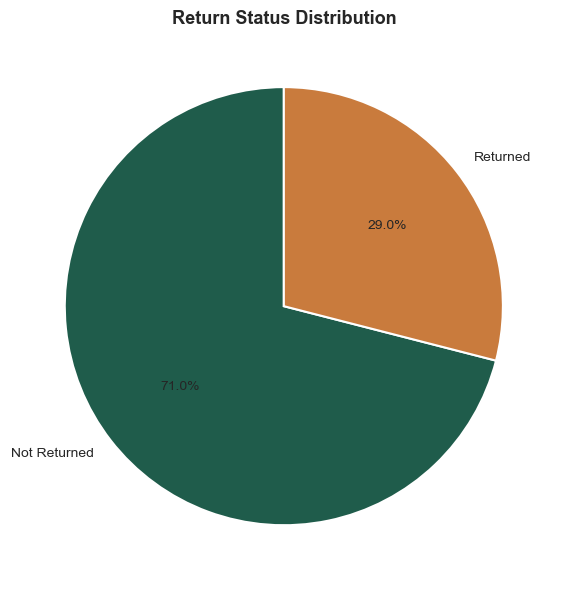

In [15]:
status_counts = df["Return_Status"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(status_counts, labels=status_counts.index, autopct="%1.1f%%", startangle=90,
        colors=[STATUS_COLORS[s] for s in status_counts.index],
        wedgeprops={"edgecolor": "white", "linewidth": 1.5})
plt.title("Return Status Distribution")
plt.tight_layout()
plt.show()

**Interpretation:**
71.0% of orders are kept and 29.0% are returned. This confirms returns are a routine, high-volume part of operations rather than a rare exception, which is why they warrant a dedicated KPI scorecard.

### B. Return Reason Distribution

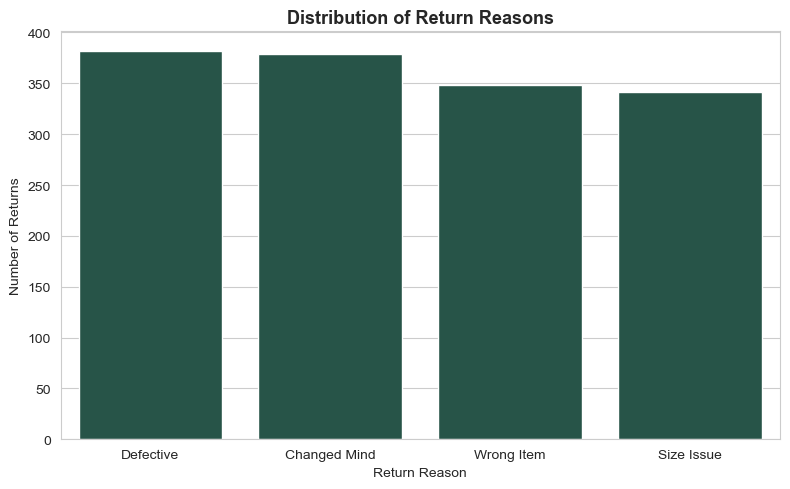

In [16]:
plt.figure(figsize=(8, 5))
order_seq = returned["Return_Reason"].value_counts().index
sns.countplot(data=returned, x="Return_Reason", order=order_seq, color=PRIMARY)
plt.title("Distribution of Return Reasons")
plt.xlabel("Return Reason")
plt.ylabel("Number of Returns")
plt.tight_layout()
plt.show()

**Interpretation:**
Defective (382) and Changed Mind (379) are the two most-cited reasons, only narrowly ahead of Wrong Item (348) and Size Issue (341). With all four reasons within a 41-order band of each other, no single reason dominates — quality, fulfilment accuracy and fit-related issues all contribute roughly equally to returns.

### C. Return Rate by Product Category

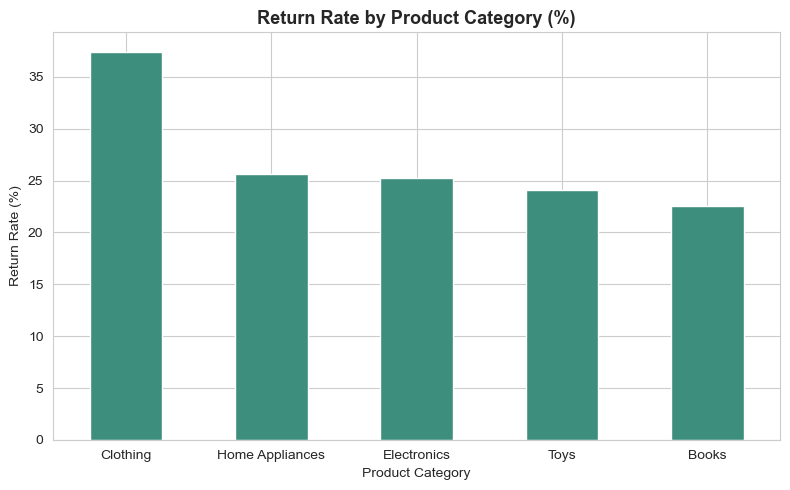

In [17]:
plt.figure(figsize=(8, 5))
return_rate_by_category.plot(kind="bar", color=SECONDARY, edgecolor="white")
plt.title("Return Rate by Product Category (%)")
plt.xlabel("Product Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:**
Clothing has the highest return rate at 37.43%, making it the most return-prone category in the dataset. This makes Clothing a priority for investigating the specific reasons behind its returns, rather than assuming any single cause without further evidence.

### D. Return Rate by Shipping Method

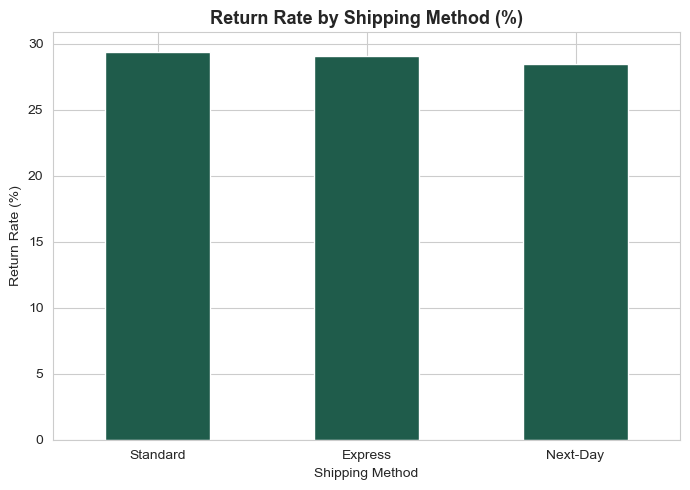

In [18]:
return_rate_by_shipping = (
    df.groupby("Shipping_Method")["Return_Status"]
      .apply(lambda x: (x == "Returned").mean() * 100)
      .sort_values(ascending=False).round(2)
)

plt.figure(figsize=(7, 5))
return_rate_by_shipping.plot(kind="bar", color=PRIMARY, edgecolor="white")
plt.title("Return Rate by Shipping Method (%)")
plt.xlabel("Shipping Method")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:**
Return rates are nearly identical across shipping methods — Standard (29.41%), Express (29.09%) and Next-Day (28.50%) — a spread of under 1 percentage point. Shipping method does not appear to be a major differentiator in return behaviour in this dataset.

### E. Return Rate by Payment Method

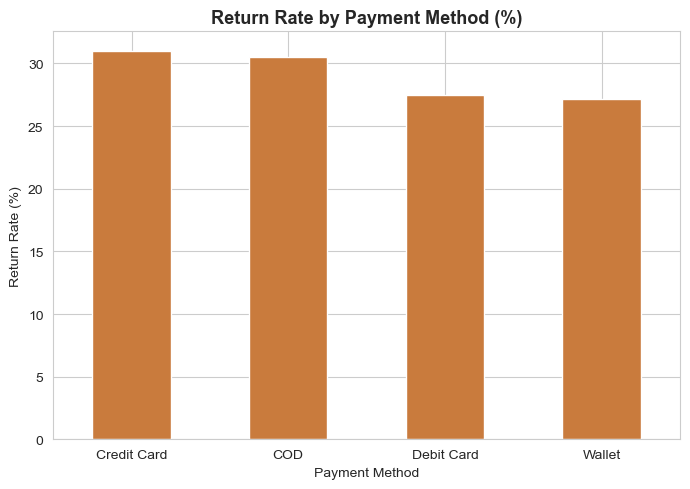

In [19]:
return_rate_by_payment = (
    df.groupby("Payment_Method")["Return_Status"]
      .apply(lambda x: (x == "Returned").mean() * 100)
      .sort_values(ascending=False).round(2)
)

plt.figure(figsize=(7, 5))
return_rate_by_payment.plot(kind="bar", color=ACCENT, edgecolor="white")
plt.title("Return Rate by Payment Method (%)")
plt.xlabel("Payment Method")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:**
Credit Card orders are associated with the highest return rate (31.01%) and Wallet orders with the lowest (27.14%) — a modest ~4 percentage point spread. This is a smaller effect than category (Section C), and the data shows an association only, not a causal link between payment method and returning an order.

### F. Monthly Return Rate Trend

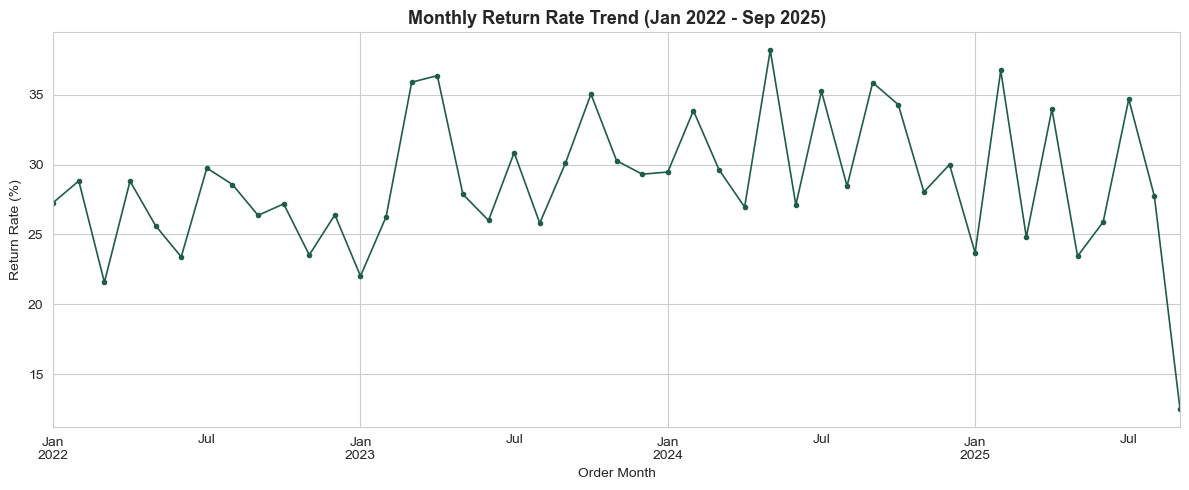

In [20]:
monthly_returns = df.copy()
monthly_returns["Order_Month"] = monthly_returns["Order_Date"].dt.to_period("M")
monthly_return_rate = (
    monthly_returns.groupby("Order_Month")["Return_Status"]
    .apply(lambda x: (x == "Returned").mean() * 100)
)

plt.figure(figsize=(12, 5))
monthly_return_rate.plot(kind="line", marker="o", markersize=3, color=PRIMARY, linewidth=1.2)
plt.title("Monthly Return Rate Trend (Jan 2022 - Sep 2025)")
plt.xlabel("Order Month")
plt.ylabel("Return Rate (%)")
plt.tight_layout()
plt.show()

**Interpretation:**
Monthly return rates fluctuate between 12.5% and 38.18%, with no consistent upward or downward movement across the observed period (Jan 2022 - Sep 2025). The month-to-month variation suggests that return behaviour changes over time, but the available data does not establish a clear long-term trend. Note that the lowest point, in the final month (September 2025), reflects only 16 orders — a partial month too small a sample to read as a genuine drop.

### G. Category × Return Reason

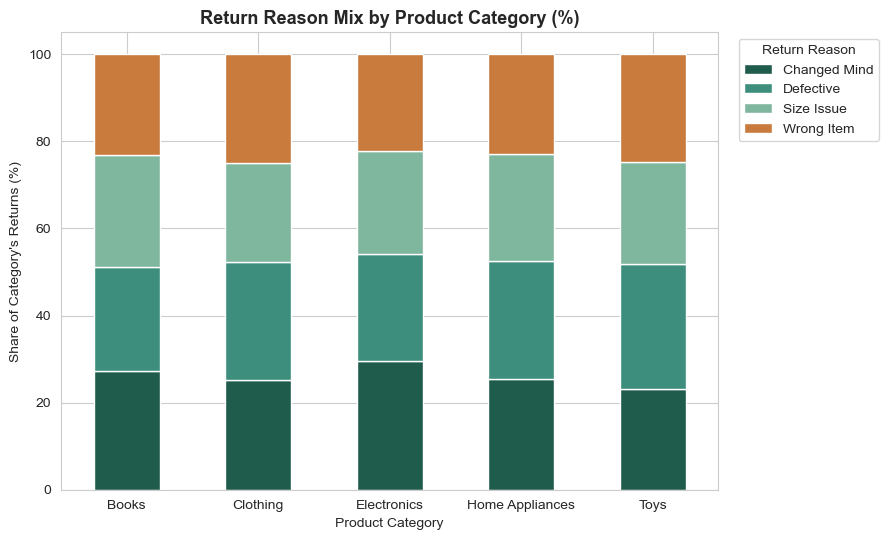

In [21]:
category_reason_pct = pd.crosstab(
    returned["Product_Category"], returned["Return_Reason"], normalize="index"
) * 100

plt.figure(figsize=(9, 5.5))
category_reason_pct.plot(kind="bar", stacked=True, color=PALETTE[:4], edgecolor="white", ax=plt.gca())
plt.title("Return Reason Mix by Product Category (%)")
plt.xlabel("Product Category")
plt.ylabel("Share of Category's Returns (%)")
plt.xticks(rotation=0)
plt.legend(title="Return Reason", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation:**
The reason mix is fairly similar across categories — each reason sits roughly in the 22-29% range within every category, including Clothing, where Size Issue (22.8%) is not disproportionately larger than the other three reasons. This means Clothing's high overall return rate (Section C) is not explained by one dominant reason; quality, fulfilment accuracy, fit and changed-mind returns all contribute in similar proportion.

## 5. Financial Impact

### A. Order Value Distribution

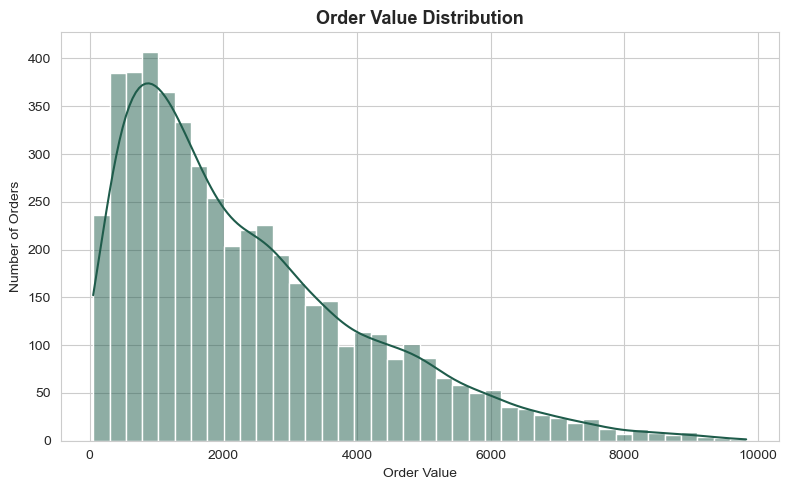

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Order_Value"], bins=40, color=PRIMARY, kde=True)
plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

**Interpretation:**
Order values are concentrated below ₹3,000 with a long right tail toward higher-value orders, consistent with the right-skew (1.10) measured in Section 2.2. This shape means summary averages should be read alongside the median (₹1,864.58), not the mean alone.

### B. Order Value by Return Status

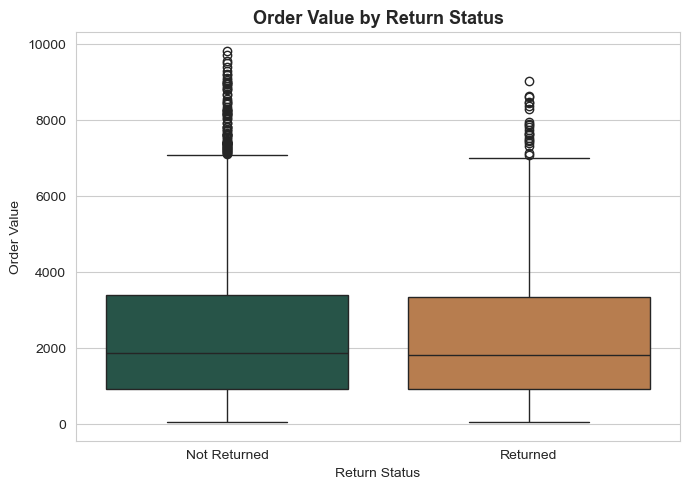

In [23]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Return_Status", y="Order_Value",
            hue="Return_Status", palette=STATUS_COLORS, legend=False)
plt.title("Order Value by Return Status")
plt.xlabel("Return Status")
plt.ylabel("Order Value")
plt.tight_layout()
plt.show()

**Interpretation:**
The order-value spread looks very similar for returned and not-returned orders, with overlapping boxes and comparable medians. Order value on its own does not appear to distinguish which orders get returned; category and reason (Section 4) show a clearer pattern.

### C. Average Profit/Loss by Return Status

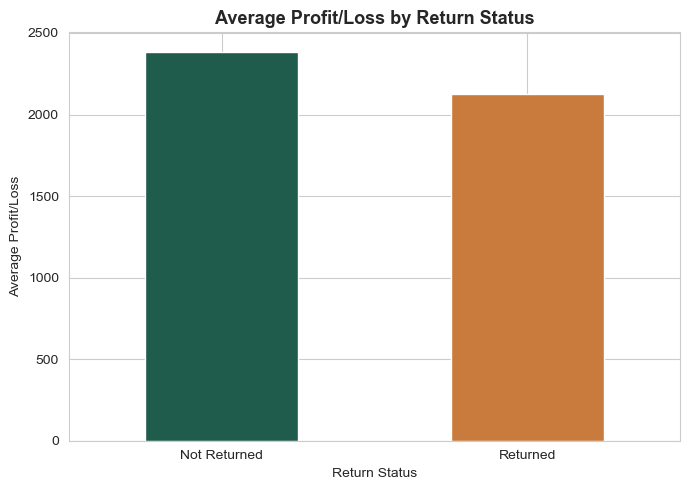

Return_Status
Not Returned    2384.67
Returned        2123.72
Name: Profit_Loss, dtype: float64

In [24]:
avg_profit_by_status = df.groupby("Return_Status")["Profit_Loss"].mean().round(2)

plt.figure(figsize=(7, 5))
avg_profit_by_status.plot(kind="bar", color=[STATUS_COLORS[s] for s in avg_profit_by_status.index],
                           edgecolor="white")
plt.title("Average Profit/Loss by Return Status")
plt.xlabel("Return Status")
plt.ylabel("Average Profit/Loss")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
avg_profit_by_status

**Interpretation:**
Returned orders show a lower average profit (₹2,123.72) than non-returned orders (₹2,384.67), a difference of about ₹260.95 per order. This indicates a measurable financial difference associated with returns — largely consistent with the flat ₹200 handling fee identified in Section 3.4 — but the dataset does not isolate every factor contributing to this gap, so the gap should be read as an association rather than a proven cause.

### D. Days to Return Distribution

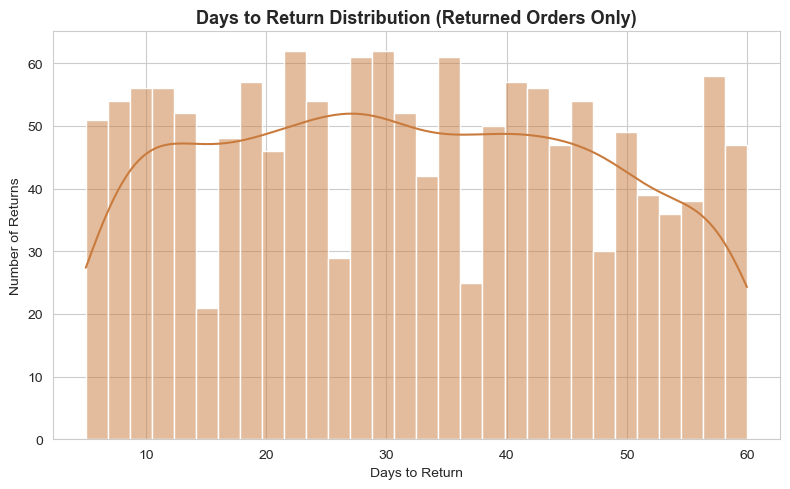

In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(returned["Days_to_Return"], bins=30, color=ACCENT, kde=True)
plt.title("Days to Return Distribution (Returned Orders Only)")
plt.xlabel("Days to Return")
plt.ylabel("Number of Returns")
plt.tight_layout()
plt.show()

**Interpretation:**
Returned orders are spread across a relatively wide return window, with most observations concentrated between approximately 5 and 60 days. The average return period of 31.74 days indicates that reverse-logistics activity can remain active well beyond the original delivery period, which is relevant for capacity and inventory planning.

## 6. Sustainability Analysis

### A. Sustainability Recovery Comparison

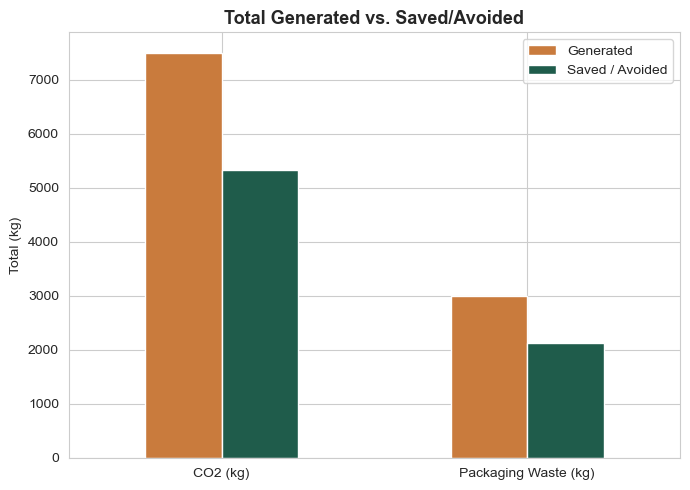

,Generated,Saved / Avoided
CO2 (kg),7500.5,5333.0
Packaging Waste (kg),2997.6,2133.4


In [26]:
sustainability_totals = pd.DataFrame({
    "Generated": [df["CO2_Emissions"].sum(), df["Packaging_Waste"].sum()],
    "Saved / Avoided": [df["CO2_Saved"].sum(), df["Waste_Avoided"].sum()],
}, index=["CO2 (kg)", "Packaging Waste (kg)"]).round(1)

sustainability_totals.plot(kind="bar", figsize=(7, 5), color=[ACCENT, PRIMARY], edgecolor="white")
plt.title("Total Generated vs. Saved/Avoided")
plt.ylabel("Total (kg)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

sustainability_totals

**Interpretation:**
The recorded CO2_Saved value represents approximately 71.1% of total CO2_Emissions, and Waste_Avoided represents approximately 71.17% of total Packaging_Waste. However, checking these fields at the order level (not shown as a separate table) shows CO2_Saved equals CO2_Emissions exactly for orders that are **not** returned, and is 0 for every returned order — the same pattern holds for Waste_Avoided against Packaging_Waste. In other words, these "saved/avoided" figures track which orders were *not* returned rather than reflecting a distinct recovery process applied to returned items, so the ~71% figures are closely tied to the 71.0% non-return rate rather than an independent sustainability outcome. The dataset does not describe what mechanism, if any, produces this pattern.

### B. Sustainability Metrics — CO₂ and Packaging Waste by Category

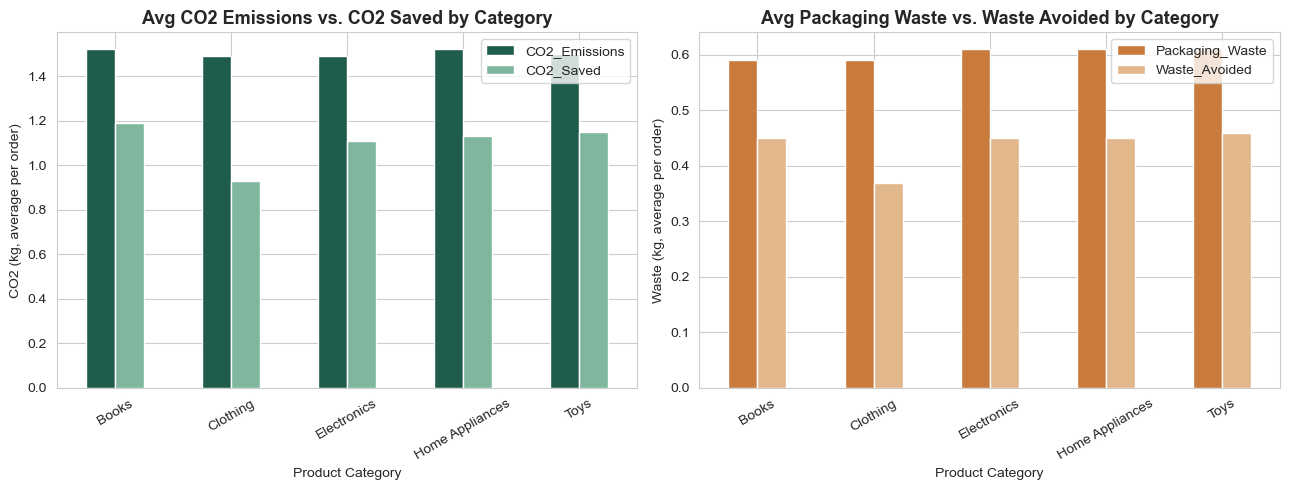

In [27]:
sustainability_by_category = df.groupby("Product_Category")[
    ["CO2_Emissions", "CO2_Saved", "Packaging_Waste", "Waste_Avoided"]
].mean().round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sustainability_by_category[["CO2_Emissions", "CO2_Saved"]].plot(
    kind="bar", ax=axes[0], color=[PRIMARY, "#7FB69E"], edgecolor="white")
axes[0].set_title("Avg CO2 Emissions vs. CO2 Saved by Category")
axes[0].set_xlabel("Product Category")
axes[0].set_ylabel("CO2 (kg, average per order)")
axes[0].tick_params(axis="x", rotation=30)

sustainability_by_category[["Packaging_Waste", "Waste_Avoided"]].plot(
    kind="bar", ax=axes[1], color=[ACCENT, "#E3B78C"], edgecolor="white")
axes[1].set_title("Avg Packaging Waste vs. Waste Avoided by Category")
axes[1].set_xlabel("Product Category")
axes[1].set_ylabel("Waste (kg, average per order)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Interpretation:**
The recorded CO₂ and packaging-waste measures vary across product categories, providing a descriptive comparison of the sustainability metrics in the dataset. However, these differences should be interpreted alongside the return-status structure identified earlier and should not be treated as evidence that one category is inherently more sustainable.

## 7. Relationship & Correlation Analysis

### A. Correlation Heatmap

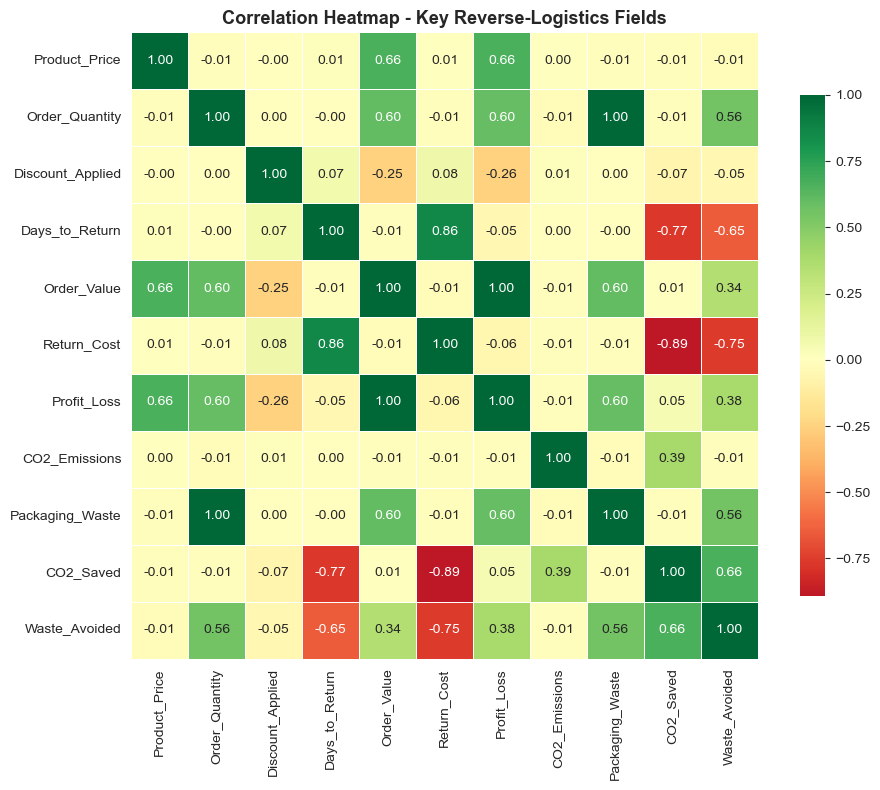

In [28]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap - Key Reverse-Logistics Fields")
plt.tight_layout()
plt.show()

**Interpretation:**
1. Order_Value and Profit_Loss correlate at 0.999 - this is a mathematical relationship, not an independent discovery, since Profit_Loss is calculated directly as Order_Value minus Return_Cost.
2. Return_Cost correlates strongly with Days_to_Return (0.86) and with CO2_Saved (-0.89) and Waste_Avoided (-0.75), but this is a structural link, not a causal one: all of these fields are tied to whether an order was returned (Return_Cost and Days_to_Return are only non-zero for returned orders; CO2_Saved and Waste_Avoided are only non-zero for non-returned orders), so the correlation reflects that shared dependency on Return_Status rather than one variable driving another.
3. Order_Quantity and Packaging_Waste correlate at 1.00 because Packaging_Waste is calculated directly from Order_Quantity in this dataset.
4. CO2_Emissions and Packaging_Waste show almost no linear relationship (-0.02) - there is little to no evidence in this data that higher emissions accompany higher packaging waste at the order level.

## 8. Key Findings

1. **Return rate:** 29.0% of all orders are returned overall — a routine, high-volume operational reality rather than a rare exception.

2. **Category concentration:** Clothing has a 37.43% return rate, well above every other category (Home Appliances 25.63%, Electronics 25.24%, Toys 24.07%, Books 22.57%) — making it the single strongest differentiator of return risk found in this dataset.

3. **Return reasons:** Defective, Changed Mind, Wrong Item and Size Issue are cited in near-equal proportion (23-26% each), both overall and within Clothing specifically — no one reason dominates, so Clothing's elevated return rate is not explained by a single cause such as sizing.

4. **Financial impact:** Returned orders average ₹260.95 less Profit_Loss than kept orders (₹2,123.72 vs. ₹2,384.67). The difference is broadly consistent with the fixed ₹200 return-cost assumption, but the dataset does not isolate all factors contributing to the gap.

5. **Sustainability:** CO2_Saved and Waste_Avoided sum to approximately 71% of total CO2_Emissions and Packaging_Waste respectively, but this ~71% figure is structurally tied to the 71.0% non-return rate (both metrics are recorded as 0 for every returned order) rather than evidence of an active return-recovery process.

## 9. Recommendations

1. **Finding:** Clothing has the highest return rate (37.43%) and the largest share of total returns of any category.
   **Recommendation:** Investigate category-specific return drivers for Clothing in more depth (e.g., customer-level feedback beyond the four coded reasons), since the current reason mix does not point to one specific cause.
   **Expected benefit:** A more targeted, evidence-based intervention (sizing, quality, or fulfilment accuracy) rather than a broad, unfocused fix.

2. **Finding:** Defective, Changed Mind, Wrong Item and Size Issue are cited in near-equal proportion, both overall and within every category.
   **Recommendation:** Address quality control (Defective) and pick-pack accuracy (Wrong Item) alongside any sizing initiative, rather than assuming fit is the primary driver.
   **Expected benefit:** A broader intervention is more likely to reduce total returns, since no single reason accounts for a majority of cases.

3. **Finding:** Return_Cost is a fixed ₹200 fee applied identically to every returned order, regardless of category, reason, order value or days to return.
   **Recommendation:** Review whether a flat return-handling cost adequately represents actual operational effort across categories and reasons — this is a data/process question for the operations team, not a basis for a new customer-facing fee, since the dataset does not show cost varying with any measurable operational factor.
   **Expected benefit:** A cost structure (if adjusted) that better reflects real handling differences, supporting more accurate profitability analysis.

4. **Finding:** Returned orders average ₹260.95 less profit than kept orders, a measurable but not isolated financial gap.
   **Recommendation:** Treat the ₹260.95 average Profit_Loss gap as a starting indicator of the financial difference associated with returned orders, and use it alongside category-level return rates to prioritise which categories offer the largest financial upside from return reduction (Clothing, given both its rate and volume).
   **Expected benefit:** A clearer, ranked view of where return-reduction effort will have the greatest financial payoff.

5. **Finding:** The ~71% CO2/waste "recovery rate" is structurally tied to the non-return rate (CO2_Saved and Waste_Avoided are 0 for every returned order), not a separate recovery mechanism visible in this dataset.
   **Recommendation:** Before reporting these figures as a "sustainability recovery achievement," clarify with the data source what CO2_Saved and Waste_Avoided are actually meant to measure, and consider whether a genuine returns-recovery metric (e.g., emissions avoided specifically through resale/refurbishment of returned items) should be tracked separately.
   **Expected benefit:** More accurate sustainability reporting, and a clearer basis for setting future recovery targets once the metric's true meaning is confirmed.

## 10. Week 3 Conclusion

This notebook used only the Week 2 cleaned dataset to build a descriptive, KPI-driven picture of ReturnLoop's reverse-logistics operation: a 29.0% overall return rate concentrated most heavily in Clothing, a fairly even mix of return reasons, a fixed ₹200 handling fee behind the ₹290,000 total cost exposure, a ~₹261 average profit gap on returned orders, and sustainability "recovery" figures that turned out to be structurally tied to the non-return rate rather than an independent recovery process. Every KPI, chart and correlation was checked against the actual computed output before being written up, and no causal claims were made from correlational or category-level patterns.

Predictive modelling of return risk, profit/loss regression, and product/category clustering remain scoped for Week 4, per the ReturnLoop roadmap set out in the Week 1 Strategic Planning Report.